In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3.common.env_checker import check_env
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
import matplotlib.pyplot as plt


In [2]:
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2022-12-31",
    interval="1d"
)


# Séparer prix et volume
price_df = data["Close"]
volume_df = data["Volume"]

price_df["CASH"] = 1.0
volume_df["CASH"] = 1.0

tickers = tickers + ["CASH"]

print(price_df.head())
print(volume_df.head())

[*********************100%***********************]  5 of 5 completed

Ticker           AAPL       AMZN      GOOGL        MSFT      NVDA  CASH
Date                                                                   
2020-01-02  72.400505  94.900497  67.873016  152.158432  5.970754   1.0
2020-01-03  71.696632  93.748497  67.517952  150.263779  5.875187   1.0
2020-01-06  72.267929  95.143997  69.317589  150.652161  5.899825   1.0
2020-01-07  71.928062  95.343002  69.183701  149.278564  5.971252   1.0
2020-01-08  73.085091  94.598503  69.676125  151.656311  5.982451   1.0
Ticker           AAPL      AMZN     GOOGL      MSFT       NVDA  CASH
Date                                                                
2020-01-02  135480400  80580000  27278000  22622100  237536000   1.0
2020-01-03  146322800  75288000  23408000  21116200  205384000   1.0
2020-01-06  118387200  81236000  46768000  20813700  262636000   1.0
2020-01-07  108872000  80898000  34330000  21634100  314856000   1.0
2020-01-08  132079200  70160000  35314000  27746500  277108000   1.0



C:\Users\erelr\AppData\Local\Temp\ipykernel_40852\3881515421.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_df["CASH"] = 1.0
C:\Users\erelr\AppData\Local\Temp\ipykernel_40852\3881515421.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volume_df["CASH"] = 1.0


In [3]:
def prepare_features(price_df: pd.DataFrame, volume_df: pd.DataFrame):
    """
    price_df  : DataFrame index=date, columns=tickers, values=close
    volume_df : DataFrame index=date, columns=tickers, values=volume

    Retourne un DataFrame multi-index colonnes:
    (ticker, feature)
    """
    tickers = list(price_df.columns)

    feats = {}
    for t in tickers:
        px = price_df[t].copy()
        vol = volume_df[t].copy()

        df_t = pd.DataFrame(index=price_df.index)

        df_t["close"] = px

        df_t["ret_1"] = px.pct_change(1)
        df_t["ret_5"] = px.pct_change(5)
        df_t["vol_20"] = px.pct_change().rolling(20).std() * np.sqrt(252)

        vol_mean = vol.rolling(20).mean()
        vol_std = vol.rolling(20).std()
        df_t["vol_z"] = (vol - vol_mean) / (vol_std + 1e-8)

        feats[t] = df_t

    panel = pd.concat(feats, axis=1)
    panel = panel.dropna().copy()
    return panel

In [4]:
prepare_features(price_df, volume_df).head()

AAPL                                                AMZN  \
                close     ret_1     ret_5    vol_20     vol_z       close   
Date                                                                        
2020-01-31  74.608582 -0.044338 -0.027646  0.280648  1.901335  100.435997   
2020-02-03  74.403679 -0.002746 -0.000938  0.277977  1.006773  100.209999   
2020-02-04  76.860008  0.033014  0.003651  0.298561 -0.176367  102.483498   
2020-02-05  77.486755  0.008154 -0.008910  0.297503 -0.762368  101.993500   
2020-02-06  78.393097  0.011697  0.004137  0.295519 -1.110964  102.511497   

                                                    ...      NVDA            \
               ret_1     ret_5    vol_20     vol_z  ...     close     ret_1   
Date                                                ...                       
2020-01-31  0.073791  0.079006  0.305346  4.042467  ...  5.884145 -0.038160   
2020-02-03 -0.002250  0.096186  0.300824  0.607842  ...  5.981206  0.016495   
2020-02-04  0.022687  0.105987  0.305970  0.376059  ...  6.150442  0.028295   
2020-02-05 -0.004781  0.097885  0.307475  0.054755  ...  6.240783  0.014688   
2020-02-06  0.005079  0.095981  0.304550 -0.351393  ...  6.327641  0.013918   

                                          CASH                           
               ret_5    vol_20     vol_z close ret_1 ret_5 vol_20 vol_z  
Date                                                                     
2020-01-31 -0.056093  0.298851  1.208184   1.0   0.0   0.0    0.0   0.0  
2020-02-03  0.000541  0.298842 -0.687509   1.0   0.0   0.0    0.0   0.0  
2020-02-04 -0.003388  0.314048 -0.430833   1.0   0.0   0.0    0.0   0.0  
2020-02-05  0.021259  0.315252 -1.331730   1.0   0.0   0.0    0.0   0.0  
2020-02-06  0.034335  0.317874 -1.089143   1.0   0.0   0.0    0.0   0.0  

[5 rows x 30 columns]

In [5]:
class MultiAssetTradingEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        features_panel,
        tickers,
        initial_cash=100000.0,
        transaction_cost=0.001,
        max_steps=252
    ):
        super().__init__()

        self.data = features_panel.copy()
        self.tickers = list(tickers)
        self.n_assets = len(self.tickers)
        self.initial_cash = float(initial_cash)
        self.transaction_cost = float(transaction_cost)
        self.max_steps = int(max_steps)

        # Features par actif
        self.asset_features = ["ret_1", "ret_5", "vol_20", "vol_z"]
        self.n_features_per_asset = len(self.asset_features)

        # Observation = features multi-actifs + poids actuels + cash ratio
        self.obs_dim = self.n_assets * self.n_features_per_asset + self.n_assets + 1

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.obs_dim,),
            dtype=np.float32
        )

        # Action globale discrète = produit cartésien des actions par actif
        # 0=HOLD, 1=BUY, 2=SELL pour chaque actif
        self.action_space = spaces.Discrete(3 ** self.n_assets)

        self.dates = self.data.index.unique().tolist()
        self._reset_internal_state()

    def _reset_internal_state(self):
        self.current_step = 0
        self.start_step = 0
        self.end_step = min(len(self.dates) - 2, self.max_steps)

        self.cash = self.initial_cash
        self.weights = np.zeros(self.n_assets, dtype=np.float64)
        self.portfolio_value = self.initial_cash
        self.portfolio_values = [self.initial_cash]
        self.n_trades = 0

    def _decode_action(self, action_int):
        # transforme un entier en vecteur base-3 de taille n_assets
        acts = []
        x = int(action_int)
        for _ in range(self.n_assets):
            acts.append(x % 3)
            x //= 3
        return np.array(acts, dtype=np.int64)

    def _get_prices(self, step):
        date = self.dates[step]
        return np.array([self.data.loc[date, (t, "close")] for t in self.tickers], dtype=np.float64)

    def _get_feature_vector(self, step):
        date = self.dates[step]
        feats = []
        for t in self.tickers:
            for f in self.asset_features:
                feats.append(self.data.loc[date, (t, f)])
        feats = np.array(feats, dtype=np.float32)

        cash_ratio = np.array([self.cash / max(self.portfolio_value, 1e-8)], dtype=np.float32)
        weights = self.weights.astype(np.float32)

        obs = np.concatenate([feats, weights, cash_ratio], axis=0)
        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._reset_internal_state()
        obs = self._get_feature_vector(self.current_step)
        info = {"portfolio_value": self.portfolio_value}
        return obs, info

    def step(self, action):
        action_vec = self._decode_action(action)

        prices_t = self._get_prices(self.current_step)
        old_value = self.portfolio_value

        # Cible simple : BUY => actif éligible pour poids égal
        # SELL => poids 0
        # HOLD => on garde le poids actuel
        target_weights = self.weights.copy()

        for i, a in enumerate(action_vec):
            if a == 1:      # BUY
                target_weights[i] = 1.0
            elif a == 2:    # SELL
                target_weights[i] = 0.0

        # normalisation en poids égaux parmi les actifs "achetés"
        if target_weights.sum() > 0:
            target_weights = (target_weights > 0).astype(np.float64)
            target_weights /= target_weights.sum()
        else:
            target_weights = np.zeros_like(target_weights)

        turnover = np.abs(target_weights - self.weights).sum()
        trading_cost = turnover * self.transaction_cost * old_value

        # passage au jour suivant
        self.current_step += 1
        prices_tp1 = self._get_prices(self.current_step)

        asset_returns = (prices_tp1 / prices_t) - 1.0
        gross_portfolio_return = np.dot(target_weights, asset_returns)

        new_value = old_value * (1.0 + gross_portfolio_return) - trading_cost
        new_value = max(new_value, 1e-8)

        self.weights = target_weights
        self.portfolio_value = new_value
        self.cash = new_value * (1.0 - self.weights.sum())  # ici souvent 0 si investi
        self.portfolio_values.append(new_value)

        if turnover > 0:
            self.n_trades += 1

        # reward simple
        reward = (new_value - old_value) / old_value

        terminated = bool(new_value <= self.initial_cash * 0.5)
        truncated = bool(self.current_step >= self.end_step)

        obs = self._get_feature_vector(self.current_step)
        info = {
            "portfolio_value": float(new_value),
            "daily_return": float(reward),
            "turnover": float(turnover),
            "n_trades": int(self.n_trades),
            "weights": self.weights.copy()
        }
        return obs, float(reward), terminated, truncated, info

    def get_metrics(self):
        values = np.array(self.portfolio_values, dtype=np.float64)
        rets = pd.Series(values).pct_change().dropna().values

        total_return = values[-1] / values[0] - 1.0
        sharpe = 0.0
        if len(rets) > 1 and np.std(rets) > 1e-12:
            sharpe = (np.mean(rets) / np.std(rets)) * np.sqrt(252)

        running_max = np.maximum.accumulate(values)
        drawdowns = values / running_max - 1.0
        max_drawdown = float(drawdowns.min())

        return {
            "total_return": float(total_return),
            "sharpe": float(sharpe),
            "max_drawdown": max_drawdown,
            "n_trades": int(self.n_trades)
        }

In [6]:
panel = prepare_features(price_df[tickers], volume_df[tickers])

env = MultiAssetTradingEnv(
    features_panel=panel,
    tickers=tickers,
    initial_cash=100000,
    transaction_cost=0.001,
    max_steps=252
)


check_env(env, warn=True)
print("Environnement valide pour SB3.")

Environnement valide pour SB3.


In [67]:
def make_env():
    return MultiAssetTradingEnv(
        features_panel=panel,
        tickers=tickers,
        initial_cash=100000,
        transaction_cost=0.001,
        max_steps=252
    )

train_env = DummyVecEnv([make_env])
train_env = VecMonitor(train_env)

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    verbose=1,
    seed=42
)

model.learn(total_timesteps=200_000)

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 252      |
|    ep_rew_mean     | 0.273    |
| time/              |          |
|    fps             | 282      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 1024     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 252        |
|    ep_rew_mean          | 0.258      |
| time/                   |            |
|    fps                  | 261        |
|    iterations           | 2          |
|    time_elapsed         | 7          |
|    total_timesteps      | 2048       |
| train/                  |            |
|    approx_kl            | 0.03895228 |
|    clip_fraction        | 0.431      |
|    clip_range           | 0.2        |
|    entropy_loss         | -6.58      |
|    explained_variance   | -9.58      |
|    learning_rate        | 

In [ ]:
model.save("ppo_multiasset_discrete")

In [11]:
model = PPO.load("ppo_multiasset_discrete")

In [7]:
def equal_weight_buy_and_hold(price_df, tickers):
    px = price_df[tickers].copy().dropna()
    daily_returns = px.pct_change().dropna()
    ew_returns = daily_returns.mean(axis=1)


    total_return = (1 + ew_returns).prod() - 1
    sharpe = 0.0
    if ew_returns.std() > 1e-12:
        sharpe = ew_returns.mean() / ew_returns.std() * np.sqrt(252)

    equity = (1 + ew_returns).cumprod()
    dd = equity / equity.cummax() - 1
    max_drawdown = dd.min()

    return {
        "total_return": float(total_return),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_drawdown)
    }

baseline = equal_weight_buy_and_hold(price_df.loc[panel.index], tickers)
print(baseline)

{'total_return': 0.46994034325823963, 'sharpe': 0.5911360486908446, 'max_drawdown': -0.3542021465503331}


In [26]:
def evaluate_trained_model(model, env, deterministic=True):
    obs, info = env.reset()
    done = False

    portfolio_values = [info["portfolio_value"]]
    dates = [env.dates[env.current_step]]
    rewards = []

    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(int(action))
        done = terminated or truncated

        rewards.append(reward)
        portfolio_values.append(info["portfolio_value"])
        dates.append(env.dates[env.current_step])

    values = np.array(portfolio_values, dtype=np.float64)
    returns = pd.Series(values).pct_change().dropna()

    total_return = values[-1] / values[0] - 1.0

    sharpe = 0.0
    if returns.std() > 1e-12:
        sharpe = returns.mean() / returns.std() * np.sqrt(252)

    running_max = np.maximum.accumulate(values)
    drawdowns = values / running_max - 1.0
    max_drawdown = drawdowns.min()

    results = {
        "total_return": float(total_return),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_drawdown),
        "final_portfolio_value": float(values[-1]),
        "avg_reward": float(np.mean(rewards)) if len(rewards) > 0 else 0.0,
        "n_steps": len(rewards),
        "n_trades": info.get("n_trades", None),
        "portfolio_values": values,
        "dates": dates
    }

    return results

## Test du model sur données jamais vue

In [9]:
tickers1 = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]

data = yf.download(
    tickers,
    start="2023-01-01",
    end="2023-07-01",
    interval="1d"
)


# Séparer prix et volume
price_df = data["Close"]
volume_df = data["Volume"]

price_df["CASH"] = 1.0
volume_df["CASH"] = 1.0

tickers = tickers1 + ["CASH"]

print(tickers)
print(price_df.head())
print(volume_df.head())

[*********************100%***********************]  6 of 6 completed

['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'CASH']
Ticker            AAPL       AMZN  CASH      GOOGL        MSFT       NVDA
Date                                                                     
2023-01-03  123.096031  85.820000   1.0  88.389465  233.452820  14.299911
2023-01-04  124.365669  85.139999   1.0  87.357994  223.240860  14.733452
2023-01-05  123.046814  83.120003   1.0  85.493401  216.624481  14.249964
2023-01-06  127.574196  86.080002   1.0  86.624039  219.177444  14.843337
2023-01-09  128.095840  87.360001   1.0  87.298477  221.311478  15.611526
Ticker           AAPL      AMZN  CASH     GOOGL      MSFT       NVDA
Date                                                                
2023-01-03  112117500  76706000   1.0  28131200  25740000  401277000
2023-01-04   89113600  68885100   1.0  34854800  50623400  431324000
2023-01-05   80962700  67930800   1.0  27194400  39585600  389168000
2023-01-06   87754700  83303400   1.0  41381500  43613600  405044000
2023-01-09   70790


C:\Users\erelr\AppData\Local\Temp\ipykernel_40852\2037665662.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_df["CASH"] = 1.0
C:\Users\erelr\AppData\Local\Temp\ipykernel_40852\2037665662.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volume_df["CASH"] = 1.0


In [10]:
panel = prepare_features(price_df[tickers], volume_df[tickers])

In [11]:
test_env = MultiAssetTradingEnv(
    features_panel=panel,
    tickers=tickers,
    initial_cash=100000,
    transaction_cost=0.001,
    max_steps=252
)

results = evaluate_trained_model(model, test_env)

print("Résultats du modèle :")
print(f"Total Return     : {results['total_return']:.2%}")
print(f"Sharpe Ratio     : {results['sharpe']:.3f}")
print(f"Max Drawdown     : {results['max_drawdown']:.2%}")
print(f"Valeur finale    : {results['final_portfolio_value']:.2f}")
print(f"Nombre de trades : {results['n_trades']}")

NameError: name 'model' is not defined

In [12]:
baseline = equal_weight_buy_and_hold(price_df.loc[panel.index], tickers1)

print("Baseline :")
print(f"Total Return : {baseline['total_return']:.2%}")
print(f"Sharpe       : {baseline['sharpe']:.3f}")
print(f"Max DD       : {baseline['max_drawdown']:.2%}")

Baseline :
Total Return : 41.94%
Sharpe       : 3.354
Max DD       : -8.33%


In [13]:
print("Comparaison IA vs baseline")
print(f"Surperformance return : {results['total_return'] - baseline['total_return']:.2%}")
print(f"Différence Sharpe     : {results['sharpe'] - baseline['sharpe']:.3f}")

Comparaison IA vs baseline


NameError: name 'results' is not defined

In [14]:
def get_ppo_portfolio_curve(model, env, deterministic=True):
    obs, info = env.reset()
    done = False

    portfolio_values = [info["portfolio_value"]]
    dates = [env.dates[env.current_step]]

    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(int(action))
        done = terminated or truncated

        portfolio_values.append(info["portfolio_value"])
        dates.append(env.dates[env.current_step])

    curve = pd.DataFrame({
        "date": dates,
        "ppo_portfolio": portfolio_values
    }).set_index("date")

    return curve

In [15]:
def get_buy_and_hold_curve(price_df, tickers, initial_cash=100000):
    px = price_df[tickers].copy().dropna()

    # Prix initiaux
    first_prices = px.iloc[0]

    # Capital réparti également
    alloc_per_asset = initial_cash / len(tickers)

    # Nombre de parts achetées au départ
    shares = alloc_per_asset / first_prices

    # Valeur du portefeuille au fil du temps
    portfolio_values = (px * shares).sum(axis=1)

    curve = pd.DataFrame({
        "buy_hold_portfolio": portfolio_values
    })

    return curve

In [16]:
test_prices = price_df.loc[panel.index, tickers].copy()

In [17]:
ppo_curve = get_ppo_portfolio_curve(model, test_env)
bh_curve = get_buy_and_hold_curve(test_prices, tickers1, initial_cash=100000)

NameError: name 'model' is not defined

In [18]:
comparison = ppo_curve.join(bh_curve, how="inner")
print(comparison.head())

NameError: name 'ppo_curve' is not defined

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(comparison.index, comparison["ppo_portfolio"], label="PPO")
plt.plot(comparison.index, comparison["buy_hold_portfolio"], label="Buy and Hold")
plt.title("Valeur du portefeuille au fil du temps")
plt.xlabel("Date")
plt.ylabel("Valeur du portefeuille")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'comparison' is not defined

<Figure size 1200x600 with 0 Axes>


# Mise en place d'un entrainement de 5 ans tout les 6 mois pendant 5ans

In [20]:
tickers = ["AAPL", "MSFT", "TSLA", "GOOGL", "AMZN"]

data = yf.download(
    tickers,
    start="2014-01-01",
    end="2025-12-31",
    interval="1d"
)


# Séparer prix et volume
price_df = data["Close"].copy()
volume_df = data["Volume"].copy()

price_df.loc[:, "CASH"] = 1.0
volume_df.loc[:, "CASH"] = 1.0

tickers = tickers + ["CASH"]

print(price_df.head())
print(volume_df.head())

[*********************100%***********************]  5 of 5 completed

Ticker           AAPL       AMZN      GOOGL       MSFT       TSLA  CASH
Date                                                                   
2014-01-02  17.140663  19.898500  27.627514  30.760921  10.006667   1.0
2014-01-03  16.764156  19.822001  27.425978  30.553968   9.970667   1.0
2014-01-06  16.855570  19.681499  27.731756  29.908289   9.800000   1.0
2014-01-07  16.735029  19.901501  28.266382  30.140072   9.957333   1.0
2014-01-08  16.841007  20.096001  28.325199  29.601992  10.085333   1.0
Ticker           AAPL      AMZN      GOOGL      MSFT      TSLA  CASH
Date                                                                
2014-01-02  234684800  42756000   72783144  30632200  92826000   1.0
2014-01-03  392467600  44204000   66601332  31134800  70425000   1.0
2014-01-06  412610800  63412000   70701228  43603700  80416500   1.0
2014-01-07  317209200  38320000  102001896  35802800  75511500   1.0
2014-01-08  258529600  46330000   89610300  59971700  92448000   1.0


In [23]:
anne = 2014
anne_ent = 5*2
for i in range(anne_ent):

    if i % 2 == 0:
        anne+=1
        deb_ent = f"{anne}-01-01"
        fint_ent = f"{anne+4}-12-31"
    else:
        deb_ent = f"{anne}-07-01"
        fint_ent = f"{anne+5}-06-30"

    price_df_per = price_df.loc[deb_ent:fint_ent]
    volume_df_per = volume_df.loc[deb_ent:fint_ent]

    #print(price_df_per.head(-1))
    #print(volume_df_per.head(-1))

    #print(prepare_features(price_df_per, volume_df_per).head())

    panel = prepare_features(price_df_per[tickers], volume_df_per[tickers])

    env = MultiAssetTradingEnv(
        features_panel=panel,
        tickers=tickers,
        initial_cash=100000,
        transaction_cost=0.001,
        max_steps=252
    )


    check_env(env, warn=True)
    print(f"Environnement valide pour SB3. Entrainement {i}")


    def make_env():
        return MultiAssetTradingEnv(
            features_panel=panel,
            tickers=tickers,
            initial_cash=100000,
            transaction_cost=0.001,
            max_steps=252
        )

    train_env = DummyVecEnv([make_env])
    train_env = VecMonitor(train_env)

    print(f"Résultats du modèle {i} de {deb_ent} -> {fint_ent}:")
"""
    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4,
        n_steps=1024,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        vf_coef=0.5,
        verbose=1,
        seed=42
    )

    model.learn(total_timesteps=200_000)

    model.save(f"ppo_multiasset_discrete_periode{i}")

"""


Environnement valide pour SB3. Entrainement 0
Résultats du modèle 0 de 2015-01-01 -> 2019-12-31:
Environnement valide pour SB3. Entrainement 1
Résultats du modèle 1 de 2015-07-01 -> 2020-06-30:
Environnement valide pour SB3. Entrainement 2
Résultats du modèle 2 de 2016-01-01 -> 2020-12-31:
Environnement valide pour SB3. Entrainement 3
Résultats du modèle 3 de 2016-07-01 -> 2021-06-30:
Environnement valide pour SB3. Entrainement 4
Résultats du modèle 4 de 2017-01-01 -> 2021-12-31:
Environnement valide pour SB3. Entrainement 5
Résultats du modèle 5 de 2017-07-01 -> 2022-06-30:
Environnement valide pour SB3. Entrainement 6
Résultats du modèle 6 de 2018-01-01 -> 2022-12-31:
Environnement valide pour SB3. Entrainement 7
Résultats du modèle 7 de 2018-07-01 -> 2023-06-30:
Environnement valide pour SB3. Entrainement 8
Résultats du modèle 8 de 2019-01-01 -> 2023-12-31:
Environnement valide pour SB3. Entrainement 9
Résultats du modèle 9 de 2019-07-01 -> 2024-06-30:


'\n    model = PPO(\n        policy="MlpPolicy",\n        env=train_env,\n        learning_rate=3e-4,\n        n_steps=1024,\n        batch_size=64,\n        n_epochs=10,\n        gamma=0.99,\n        gae_lambda=0.95,\n        clip_range=0.2,\n        ent_coef=0.01,\n        vf_coef=0.5,\n        verbose=1,\n        seed=42\n    )\n\n    model.learn(total_timesteps=200_000)\n\n    model.save(f"ppo_multiasset_discrete_periode{i}")\n\n'

In [22]:
anne = 2019
anne_ent = 5*2
for i in range(anne_ent):

    if i % 2 == 0:
        anne+=1
        deb_ent = f"{anne}-01-01"
        fint_ent = f"{anne}-06-30"
    else:
        deb_ent = f"{anne}-07-01"
        fint_ent = f"{anne}-12-31"

    price_df_per = price_df.loc[deb_ent:fint_ent]
    volume_df_per = volume_df.loc[deb_ent:fint_ent]

    model = PPO.load(f"ppo_multiasset_discrete_periode{i}")

    panel = prepare_features(price_df_per[tickers], volume_df_per[tickers])
    #print(panel)

    test_env = MultiAssetTradingEnv(
        features_panel=panel,
        tickers=tickers,
        initial_cash=100000,
        transaction_cost=0.001,
        max_steps=252)


    results = evaluate_trained_model(model, test_env)

    print(f"Résultats du modèle {i} de {deb_ent} -> {fint_ent}:")
    print(f"Total Return     : {results['total_return']:.2%}")
    print(f"Sharpe Ratio     : {results['sharpe']:.3f}")
    print(f"Max Drawdown     : {results['max_drawdown']:.2%}")
    print(f"Valeur finale    : {results['final_portfolio_value']:.2f}")
    print(f"Nombre de trades : {results['n_trades']}")
    print()


Résultats du modèle 0 de 2020-01-01 -> 2020-06-30:
Total Return     : 21.25%
Sharpe Ratio     : 1.159
Max Drawdown     : -38.21%
Valeur finale    : 121245.25
Nombre de trades : 70

Résultats du modèle 1 de 2020-07-01 -> 2020-12-31:
Total Return     : 35.63%
Sharpe Ratio     : 2.360
Max Drawdown     : -18.24%
Valeur finale    : 135633.52
Nombre de trades : 64

Résultats du modèle 2 de 2021-01-01 -> 2021-06-30:
Total Return     : -10.24%
Sharpe Ratio     : -0.454
Max Drawdown     : -22.63%
Valeur finale    : 89761.57
Nombre de trades : 55

Résultats du modèle 3 de 2021-07-01 -> 2021-12-31:
Total Return     : 23.84%
Sharpe Ratio     : 1.797
Max Drawdown     : -10.68%
Valeur finale    : 123838.73
Nombre de trades : 75

Résultats du modèle 4 de 2022-01-01 -> 2022-06-30:
Total Return     : -28.01%
Sharpe Ratio     : -1.924
Max Drawdown     : -31.24%
Valeur finale    : 71986.04
Nombre de trades : 63

Résultats du modèle 5 de 2022-07-01 -> 2022-12-31:
Total Return     : -32.89%
Sharpe Ratio   

In [24]:
anne = 2019
anne_ent = 5*2
cash =100000
for i in range(anne_ent):

    if i % 2 == 0:
        anne+=1
        deb_ent = f"{anne}-01-01"
        fint_ent = f"{anne}-06-30"
    else:
        deb_ent = f"{anne}-07-01"
        fint_ent = f"{anne}-12-31"

    price_df_per = price_df.loc[deb_ent:fint_ent]
    volume_df_per = volume_df.loc[deb_ent:fint_ent]

    model = PPO.load(f"ppo_multiasset_discrete_periode{i}")

    panel = prepare_features(price_df_per[tickers], volume_df_per[tickers])
    #print(panel)

    test_env = MultiAssetTradingEnv(
        features_panel=panel,
        tickers=tickers,
        initial_cash=cash,
        transaction_cost=0.001,
        max_steps=252)


    results = evaluate_trained_model(model, test_env)

    print(f"Résultats du modèle {i} de {deb_ent} -> {fint_ent}:")
    print(f"Total Return     : {results['total_return']:.2%}")
    print(f"Sharpe Ratio     : {results['sharpe']:.3f}")
    print(f"Max Drawdown     : {results['max_drawdown']:.2%}")
    print(f"Valeur finale    : {results['final_portfolio_value']:.2f}")
    print(f"Nombre de trades : {results['n_trades']}")
    print()
    cash = results['final_portfolio_value']

Résultats du modèle 0 de 2020-01-01 -> 2020-06-30:
Total Return     : 21.25%
Sharpe Ratio     : 1.159
Max Drawdown     : -38.21%
Valeur finale    : 121245.25
Nombre de trades : 70

Résultats du modèle 1 de 2020-07-01 -> 2020-12-31:
Total Return     : 35.63%
Sharpe Ratio     : 2.360
Max Drawdown     : -18.24%
Valeur finale    : 164449.19
Nombre de trades : 64

Résultats du modèle 2 de 2021-01-01 -> 2021-06-30:
Total Return     : -10.24%
Sharpe Ratio     : -0.454
Max Drawdown     : -22.63%
Valeur finale    : 147612.18
Nombre de trades : 55

Résultats du modèle 3 de 2021-07-01 -> 2021-12-31:
Total Return     : 23.84%
Sharpe Ratio     : 1.797
Max Drawdown     : -10.68%
Valeur finale    : 182801.04
Nombre de trades : 75

Résultats du modèle 4 de 2022-01-01 -> 2022-06-30:
Total Return     : -28.01%
Sharpe Ratio     : -1.924
Max Drawdown     : -31.24%
Valeur finale    : 131591.22
Nombre de trades : 63

Résultats du modèle 5 de 2022-07-01 -> 2022-12-31:
Total Return     : -32.89%
Sharpe Ratio 

In [27]:
all_curves = []
all_metrics = []

anne = 2019
anne_ent = 5 * 2
cash = 100000

for i in range(anne_ent):

    if i % 2 == 0:
        anne += 1
        deb_ent = f"{anne}-01-01"
        fint_ent = f"{anne}-06-30"
    else:
        deb_ent = f"{anne}-07-01"
        fint_ent = f"{anne}-12-31"

    price_df_per = price_df.loc[deb_ent:fint_ent]
    volume_df_per = volume_df.loc[deb_ent:fint_ent]

    model = PPO.load(f"ppo_multiasset_discrete_periode{i}")

    panel = prepare_features(price_df_per[tickers], volume_df_per[tickers])

    test_env = MultiAssetTradingEnv(
        features_panel=panel,
        tickers=tickers,
        initial_cash=cash,
        transaction_cost=0.001,
        max_steps=252
    )

    results = evaluate_trained_model(model, test_env)

    print(f"Résultats du modèle {i} de {deb_ent} -> {fint_ent}:")
    print(f"Total Return     : {results['total_return']:.2%}")
    print(f"Sharpe Ratio     : {results['sharpe']:.3f}")
    print(f"Max Drawdown     : {results['max_drawdown']:.2%}")
    print(f"Valeur finale    : {results['final_portfolio_value']:.2f}")
    print(f"Nombre de trades : {results['n_trades']}")
    print()

    # stocker la courbe de cette fenêtre
    curve_df = pd.DataFrame({
        "date": results["dates"],
        "ppo_portfolio": results["portfolio_values"]
    }).drop_duplicates(subset="date").set_index("date")

    curve_df["window_id"] = i
    all_curves.append(curve_df)

    # stocker les métriques de cette fenêtre
    all_metrics.append({
        "window_id": i,
        "start": deb_ent,
        "end": fint_ent,
        "total_return": results["total_return"],
        "sharpe": results["sharpe"],
        "max_drawdown": results["max_drawdown"],
        "final_value": results["final_portfolio_value"],
        "n_trades": results["n_trades"]
    })

    # chaîner le capital
    cash = results["final_portfolio_value"]

# courbe PPO complète
ppo_curve = pd.concat(all_curves).sort_index()
ppo_curve = ppo_curve[~ppo_curve.index.duplicated(keep="first")]

# tableau résumé
metrics_df = pd.DataFrame(all_metrics)

print(metrics_df)

Résultats du modèle 0 de 2020-01-01 -> 2020-06-30:
Total Return     : 21.25%
Sharpe Ratio     : 1.159
Max Drawdown     : -38.21%
Valeur finale    : 121245.25
Nombre de trades : 70

Résultats du modèle 1 de 2020-07-01 -> 2020-12-31:
Total Return     : 35.63%
Sharpe Ratio     : 2.360
Max Drawdown     : -18.24%
Valeur finale    : 164449.19
Nombre de trades : 64

Résultats du modèle 2 de 2021-01-01 -> 2021-06-30:
Total Return     : -10.24%
Sharpe Ratio     : -0.454
Max Drawdown     : -22.63%
Valeur finale    : 147612.18
Nombre de trades : 55

Résultats du modèle 3 de 2021-07-01 -> 2021-12-31:
Total Return     : 23.84%
Sharpe Ratio     : 1.797
Max Drawdown     : -10.68%
Valeur finale    : 182801.04
Nombre de trades : 75

Résultats du modèle 4 de 2022-01-01 -> 2022-06-30:
Total Return     : -28.01%
Sharpe Ratio     : -1.924
Max Drawdown     : -31.24%
Valeur finale    : 131591.22
Nombre de trades : 63

Résultats du modèle 5 de 2022-07-01 -> 2022-12-31:
Total Return     : -32.89%
Sharpe Ratio 

In [28]:
baseline_tickers = [t for t in tickers if t != "CASH"]

In [29]:
def get_buy_and_hold_curve2(price_df, tickers, start_date, end_date, initial_cash=100000):
    px = price_df.loc[start_date:end_date, tickers].copy().dropna()

    # achat au début, puis on garde
    first_prices = px.iloc[0]
    alloc_per_asset = initial_cash / len(tickers)
    shares = alloc_per_asset / first_prices

    portfolio_values = (px * shares).sum(axis=1)

    curve = pd.DataFrame({
        "buy_hold_portfolio": portfolio_values
    })

    return curve

In [31]:
start_date = ppo_curve.index.min()
end_date = ppo_curve.index.max()

baseline_tickers = [t for t in tickers if t != "CASH"]

bh_curve = get_buy_and_hold_curve2(
    price_df=price_df,
    tickers=baseline_tickers,
    start_date=start_date,
    end_date=end_date,
    initial_cash=100000
)

In [32]:
comparison = ppo_curve[["ppo_portfolio"]].join(bh_curve, how="inner")
print(comparison.head())

            ppo_portfolio  buy_hold_portfolio
2020-01-31  100000.000000       100000.000000
2020-02-03  109734.921259       105062.056843
2020-02-04  112114.780041       109619.758946
2020-02-05  111940.181766       104989.381137
2020-02-06  114146.792157       106629.768605


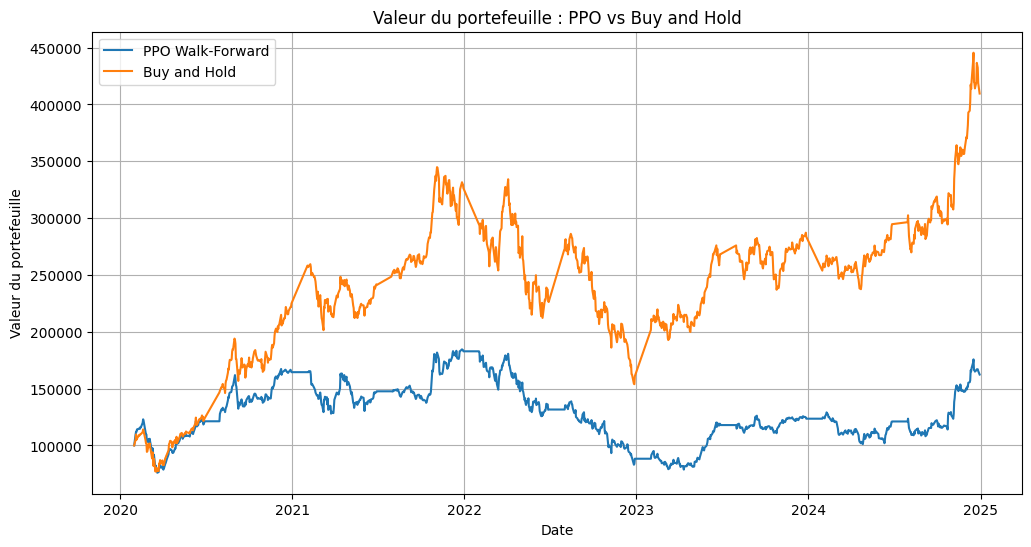

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(comparison.index, comparison["ppo_portfolio"], label="PPO Walk-Forward")
plt.plot(comparison.index, comparison["buy_hold_portfolio"], label="Buy and Hold")
plt.title("Valeur du portefeuille : PPO vs Buy and Hold")
plt.xlabel("Date")
plt.ylabel("Valeur du portefeuille")
plt.legend()
plt.grid(True)
plt.show()

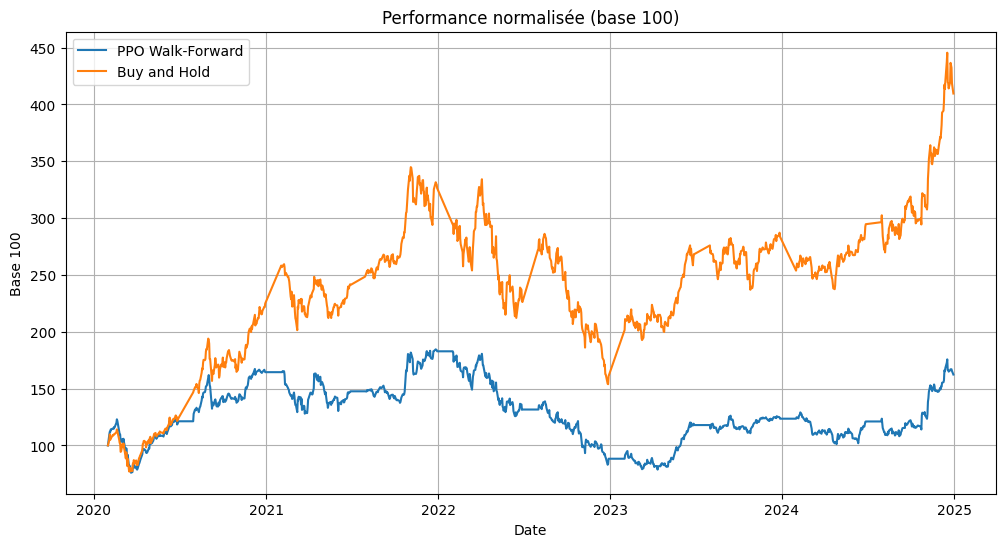

In [35]:
comparison_norm = comparison / comparison.iloc[0] * 100

plt.figure(figsize=(12, 6))
plt.plot(comparison_norm.index, comparison_norm["ppo_portfolio"], label="PPO Walk-Forward")
plt.plot(comparison_norm.index, comparison_norm["buy_hold_portfolio"], label="Buy and Hold")
plt.title("Performance normalisée (base 100)")
plt.xlabel("Date")
plt.ylabel("Base 100")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
def compute_curve_metrics(curve: pd.Series):
    returns = curve.pct_change().dropna()

    total_return = curve.iloc[-1] / curve.iloc[0] - 1.0

    sharpe = 0.0
    if returns.std() > 1e-12:
        sharpe = returns.mean() / returns.std() * np.sqrt(252)

    running_max = curve.cummax()
    drawdown = curve / running_max - 1.0
    max_drawdown = drawdown.min()

    return {
        "total_return": float(total_return),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_drawdown)
    }

In [37]:
ppo_metrics_global = compute_curve_metrics(comparison["ppo_portfolio"])
bh_metrics_global = compute_curve_metrics(comparison["buy_hold_portfolio"])

print("=== PPO Walk-Forward ===")
print(f"Total Return : {ppo_metrics_global['total_return']:.2%}")
print(f"Sharpe       : {ppo_metrics_global['sharpe']:.3f}")
print(f"Max DD       : {ppo_metrics_global['max_drawdown']:.2%}")

print("\n=== Buy and Hold ===")
print(f"Total Return : {bh_metrics_global['total_return']:.2%}")
print(f"Sharpe       : {bh_metrics_global['sharpe']:.3f}")
print(f"Max DD       : {bh_metrics_global['max_drawdown']:.2%}")

=== PPO Walk-Forward ===
Total Return : 62.36%
Sharpe       : 0.503
Max DD       : -57.34%

=== Buy and Hold ===
Total Return : 309.56%
Sharpe       : 1.003
Max DD       : -55.37%
